# Лабораторна 8 — Візуалізація високовимірних даних


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 8  
**Тема лабораторної:** Візуалізація високовимірних даних

## Цілі лабораторної

- PCA як базовий метод візуалізації 
- t-SNE - реалізація з нуля 
- Навчання t-SNE та крива KL-дивергенції 
- Вплив параметра perplexity 
- Порівняння: PCA, t-SNE (власний), t-SNE (sklearn), UMAP 


## Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits, fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE as SklearnTSNE

import pca_svd_solution as pca_module
importlib.reload(pca_module)

import dim_viz_solution as viz
importlib.reload(viz)

# umap-learn: install once with  pip install umap-learn
import umap

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

SEED   = 42
COLORS = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83',
          '#A6DBA0', '#C2A5CF', '#E08214', '#4D9221', '#8073AC']
np.random.seed(SEED)


---
## 1. - PCA як базовий метод візуалізації

У тижні 7 ви реалізували PCA через власний розклад коваріаційної матриці.
Нагадаємо ключову ідею: PCA шукає такий лінійний підпростір, у якому
збережено максимальну дисперсію вихідних даних.

$$Z = (X - \mu)\, V_k, \quad V_k \in \mathbb{R}^{d \times k}$$

де стовпці $V_k$ - це $k$ власних векторів коваріаційної матриці, що відповідають
найбільшим власним значенням.

**Датасет:** `load_digits` - 1 797 зображень цифр 0–9 розміром 8×8 пікселів (64 ознаки).
Ми відбираємо рівно по 30 зразків на клас (300 разом), щоб власний t-SNE
у наступних частинах завершувався за розумний час.

**Чому PCA - базовий рівень?** Він детермінований, швидкий і добре відомий.
Якщо t-SNE або UMAP не дають кращого розділення, ніж PCA - це сигнал, що
або дані справді лінійно роздільні, або щось пішло не так з налаштуванням.

In [5]:
# Load and subsample digits
digits   = load_digits()
X_full   = digits.data    # (1797, 64)
y_full   = digits.target  # labels 0-9

# 30 samples per class -> balanced 300-sample subset
rng = np.random.RandomState(SEED)
idx = []
for c in range(10):
    class_idx = np.where(y_full == c)[0]
    idx.extend(rng.choice(class_idx, size=30, replace=False))
idx      = np.array(idx)
X_sub    = X_full[idx]
y_sub    = y_full[idx]

# Standardise: zero mean, unit variance per feature
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

print(f'Subset shape : {X_sub.shape}   (300 samples x 64 features)')
print(f'Classes      : {np.unique(y_sub)}')

Subset shape : (300, 64)   (300 samples x 64 features)
Classes      : [0 1 2 3 4 5 6 7 8 9]


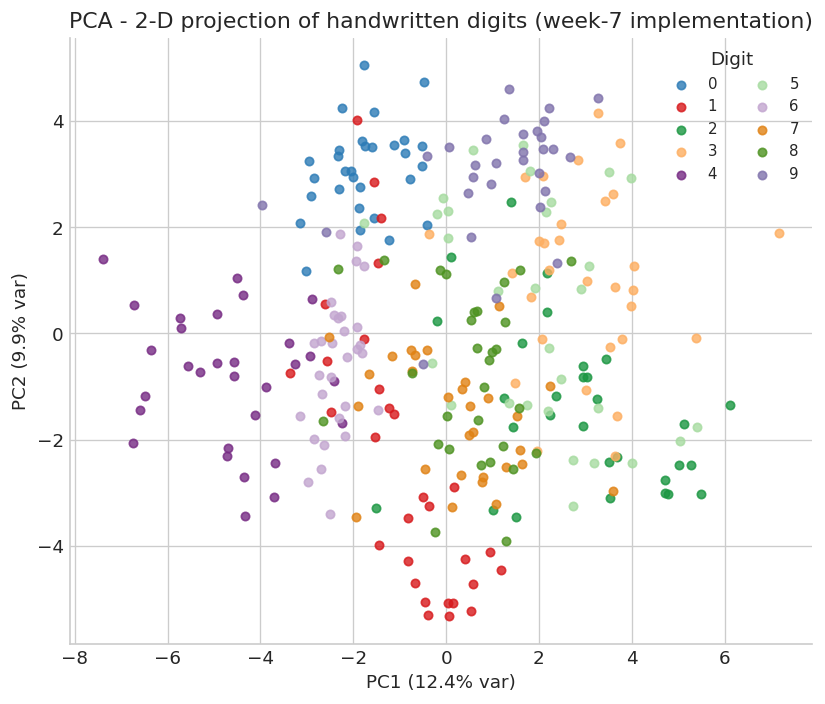

Variance captured by 2 PCs: 22.3%


In [6]:
# PCA to 2-D using the week-7 implementation
pca   = pca_module.PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
for c, col in zip(range(10), COLORS):
    mask = y_sub == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=col, label=str(c), s=25, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA - 2-D projection of handwritten digits (week-7 implementation)')
ax.legend(title='Digit', ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

total_var = pca.explained_variance_ratio_.sum()
print(f'Variance captured by 2 PCs: {total_var*100:.1f}%')

#### Що ми бачимо

Перші дві головні компоненти захоплюють лише ~22% загальної дисперсії -
решта 78% просто відкидається. Це означає, що ми зберігаємо дуже мало
інформації з 64 вихідних вимірів.

На графіку видно кілька проблем:

- Деякі цифри утворюють помітні групи (наприклад, **0** і **4** зазвичай відокремлені),
  але більшість класів сильно перекриваються в центрі.
- Цифри **3**, **5** і **8** мають схоже написання і майже нерозрізнені в цьому просторі.
- PCA не знає про мітки класів: він максимізує загальну дисперсію,
  а не відстань між класами. Тому відокремлення кластерів - лише побічний ефект.

Це і є основна мотивація для t-SNE та UMAP: вони оптимізують вкладення
безпосередньо під структуру сусідства, а не під дисперсію.

---
## 2. - t-SNE: реалізація з нуля

### Основна ідея простими словами

Уявіть, що кожна точка в датасеті - це людина на вечірці. PCA каже:
*«Давайте спроектуємо всіх на той напрямок, де люди найбільш розкидані».*
t-SNE каже інакше: *«Давайте розсадимо людей так, щоб друзі сиділи поруч,
а незнайомці - далеко, незалежно від напрямку».*

Технічно це реалізується через дві матриці ймовірностей:

| | Вихідний простір ($d$-D) | Простір вкладення (2-D) |
|---|---|---|
| **Ядро** | Гаусів | Стьюдент-$t$ (тяжкий хвіст) |
| **Матриця** | $P$ - «хто з ким дружить» у $d$-D | $Q$ - «хто з ким дружить» у 2-D |
| **Параметр** | $\sigma_i$ - ширина кола дружби | фіксована (d.f. = 1) |

Ціль: знайти таке 2-D розташування $Y$, щоб $Q$ якомога точніше відтворювало $P$.
Міра розбіжності між двома розподілами - **KL-дивергенція**:
$$\mathcal{L} = \mathrm{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Мінімізуємо $\mathcal{L}$ градієнтним спуском по координатах $Y$.

### Навіщо розподіл Стьюдента у 2-D?

У $d$-D просторі точок «багато місця»: $n$ точок можуть бути помірно далеко одна від одної.
Але в 2-D місця мало. Якщо використовувати Гаусів розподіл в обох просторах,
алгоритм намагається «запхати» всі помірно далекі точки в центр - виникає
**проблема тісноти (crowding)**. Тяжкий хвіст розподілу Стьюдента дозволяє
помірно далеким точкам бути набагато далі у 2-D без штрафу - кластери
«розтягуються» і стають візуально чіткішими.

---
Реалізуйте всі функції у файлі `dim_viz_student.py`, потім запускайте тести нижче.

### 2a - Попарні квадрати відстаней

Першим кроком потрібно виміряти, наскільки точки схожі одна на одну в $d$-D.
Основа для цього - матриця квадратів евклідових відстаней $D \in \mathbb{R}^{n \times n}$:
$$D_{ij} = \|x_i - x_j\|^2$$

Замість подвійного циклу використовуємо тотожність розкладання:
$$\|x_i - x_j\|^2 = \|x_i\|^2 + \|x_j\|^2 - 2\,x_i^\top x_j$$

Це дозволяє обчислити всю матрицю $D$ через одне матричне множення.

Реалізуйте `pairwise_sq_distances(X)`.

In [7]:
importlib.reload(viz)

D = viz.pairwise_sq_distances(X_scaled)

assert D.shape == (300, 300),       f'Expected (300,300), got {D.shape}'
assert np.allclose(np.diag(D), 0), 'Diagonal must be zero (self-distance)'
assert (D >= 0).all(),              'All distances must be non-negative'
assert np.allclose(D, D.T),         'Distance matrix must be symmetric'

nn_dist = np.sort(D, axis=1)[:, 1].mean()  # mean distance to nearest neighbour
print(f'pairwise_sq_distances OK')
print(f'Mean nearest-neighbour sq distance: {nn_dist:.2f}')

pairwise_sq_distances OK
Mean nearest-neighbour sq distance: 24.77


### 2b - Умовні ймовірності та perplexity

Для кожної точки $i$ ми хочемо визначити, з якою ймовірністю вона «обирає» точку $j$
як сусіда. Використовуємо Гаусів розподіл з центром у $x_i$:
$$p_{j|i} = \frac{\exp\!\left(-\|x_i - x_j\|^2 / 2\sigma_i^2\right)}
{\sum_{k \neq i} \exp\!\left(-\|x_i - x_k\|^2 / 2\sigma_i^2\right)}$$

Параметр $\sigma_i$ - «радіус кола дружби» точки $i$. Він підбирається окремо
для кожної точки через **perplexity** - інтуїтивно це *ефективна кількість сусідів*:
$$\text{Perp}(P_i) = 2^{H(P_i)}, \quad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$

Якщо `perplexity = 30`, алгоритм підбирає $\sigma_i$ так, щоб кожна точка
мала ~30 "значущих" сусідів. Оскільки perplexity монотонно зростає із $\sigma_i$,
знайти потрібне $\sigma_i$ можна **бінарним пошуком**.

Реалізуйте `gaussian_affinities` та `find_sigma`.

In [8]:
importlib.reload(viz)

# Test gaussian_affinities
p_row = viz.gaussian_affinities(D[0], sigma=5.0)
assert abs(p_row.sum() - 1.0) < 1e-9, 'Row must sum to 1'
assert p_row[0] == 0.0,               'Self-probability must be zero'
assert (p_row >= 0).all(),             'All entries non-negative'
print('gaussian_affinities OK')

# Test find_sigma: achieved perplexity must match the target
print('\nBinary search check (target vs achieved perplexity):')
for target_perp in [5.0, 15.0, 30.0, 50.0]:
    sigma    = viz.find_sigma(D[0], perplexity=target_perp)
    p_check  = viz.gaussian_affinities(D[0], sigma)
    achieved = viz._perplexity_of(p_check)
    status   = 'OK' if abs(achieved - target_perp) < 0.1 else 'FAIL'
    print(f'  target={target_perp:5.1f}  sigma={sigma:.4f}  '
          f'achieved={achieved:.4f}  [{status}]')
print('find_sigma OK')

gaussian_affinities OK

Binary search check (target vs achieved perplexity):
  target=  5.0  sigma=1.3938  achieved=5.0000  [OK]
  target= 15.0  sigma=1.7999  achieved=15.0000  [OK]
  target= 30.0  sigma=2.0636  achieved=30.0000  [OK]
  target= 50.0  sigma=2.2927  achieved=50.0000  [OK]
find_sigma OK


### 2c - Симетрична матриця $P$

Умовні ймовірності $p_{j|i}$ та $p_{i|j}$ не обов'язково рівні
(радіус $\sigma_i$ у кожної точки свій). Для симетричності використовуємо:
$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

Завдяки діленню на $2n$ вся матриця $P$ сумується рівно до 1,
і ми можемо трактувати $P$ як спільний розподіл ймовірностей на парах точок.

Реалізуйте `compute_P`. Очікуйте **~15–30 секунд** - бінарний пошук
запускається по черзі для кожної з 300 точок.

In [9]:
importlib.reload(viz)

t0 = time.time()
P  = viz.compute_P(X_scaled, perplexity=30.0)
print(f'compute_P done in {time.time()-t0:.1f}s')

assert P.shape == (300, 300),       f'Expected (300,300), got {P.shape}'
assert abs(P.sum() - 1.0) < 1e-5,  f'P should sum to 1, got {P.sum():.6f}'
assert np.allclose(P, P.T),         'P must be symmetric'
assert (P >= 0).all(),              'P must be non-negative'
print(f'P OK:  sum={P.sum():.6f}   min={P.min():.2e}   max={P.max():.6f}')

compute_P done in 0.2s
P OK:  sum=1.000000   min=0.00e+00   max=0.001208


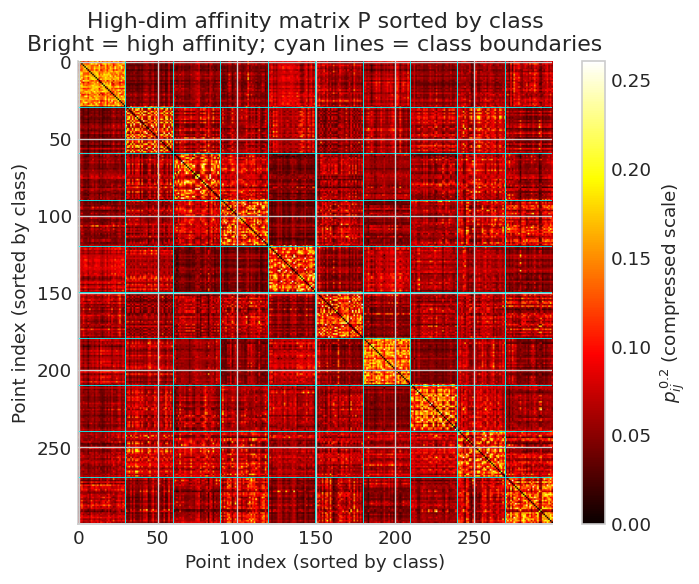

In [10]:
# Visualise P sorted by class - expect a block-diagonal pattern:
# same-class points should have higher mutual affinity
sort_idx = np.argsort(y_sub)
P_sorted = P[np.ix_(sort_idx, sort_idx)]

fig, ax = plt.subplots(figsize=(6, 5))
# Raise to 0.2 power to compress the dynamic range and reveal weak blocks
im = ax.imshow(P_sorted ** 0.2, cmap='hot', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$p_{ij}^{\,0.2}$ (compressed scale)')
ax.set_title('High-dim affinity matrix P sorted by class\n'
             'Bright = high affinity; cyan lines = class boundaries')
boundaries = np.cumsum([30] * 9)
for b in boundaries:
    ax.axhline(b - 0.5, color='cyan', lw=0.5)
    ax.axvline(b - 0.5, color='cyan', lw=0.5)
ax.set_xlabel('Point index (sorted by class)')
ax.set_ylabel('Point index (sorted by class)')
plt.tight_layout(); plt.show()

#### Що ми бачимо

Матриця $P$ - це «карта дружби» між усіма 300 точками у 64-вимірному просторі.

- **Яскраві квадрати вздовж діагоналі** (між синіми лініями) означають,
  що точки з одного класу справді є сусідами одна одної у вихідному просторі.
  Чим яскравіший квадрат - тим компактніший клас.
- **Яскраві позадіагональні ділянки** вказують на схожість між класами.
  Наприклад, якщо блок для цифр 3 і 5 виглядає яскравіше за решту -
  ці цифри мають схоже написання і знаходяться близько в просторі ознак.
- **Тьмяний фон** відповідає парам точок з різних, несхожих класів;
  $p_{ij}$ для них близьке до мінімального порогу $10^{-12}$.

t-SNE намагатиметься побудувати 2-D вкладення, де картинка $Q$ виглядатиме
якомога схожіше на цю $P$.

### 2d - Низьковимірні спорідненості $Q$ (розподіл Стьюдента)

У просторі вкладення $Y \in \mathbb{R}^{n \times 2}$ t-SNE використовує
**розподіл Стьюдента-$t$** (з одним ступенем свободи, він же розподіл Коші):
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\displaystyle\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

Порівняйте знаменники $P$ і $Q$:

| | $P$ (в $d$-D) | $Q$ (в 2-D) |
|---|---|---|
| Функція ваги | $e^{-d^2 / 2\sigma^2}$ (Гаусів) | $(1 + d^2)^{-1}$ (Стьюдент-$t$) |
| При великих $d$ | спадає дуже швидко (exponential) | спадає повільно (polynomial) |

Завдяки повільному спаданню $(1+d^2)^{-1}$ далекі точки у 2-D «коштують» менше:
алгоритм не намагається зігнати все в центр.

Реалізуйте `compute_Q`.

In [11]:
importlib.reload(viz)

# Use near-zero Y to verify that Q is nearly uniform:
# when all points are almost at the same position,
# all pairwise distances are ~0, so all weights are ~1,
# and Q becomes a uniform distribution over all pairs.
Y_near_zero = np.random.RandomState(SEED).randn(300, 2) * 1e-4
Q_uniform   = viz.compute_Q(Y_near_zero)

assert Q_uniform.shape == (300, 300),       f'Expected (300,300), got {Q_uniform.shape}'
assert abs(Q_uniform.sum() - 1.0) < 1e-5,  f'Q should sum to 1, got {Q_uniform.sum():.6f}'
assert np.allclose(Q_uniform, Q_uniform.T), 'Q must be symmetric'
assert (Q_uniform >= 0).all(),              'Q must be non-negative'

# std is near-zero because Q is nearly uniform (all values are ~1/(n*(n-1)))
Q_std = Q_uniform[Q_uniform > 1e-11].std()
print(f'compute_Q OK')
print(f'Q std with near-zero Y: {Q_std:.2e}  (expected: close to 0, Q is uniform)')

compute_Q OK
Q std with near-zero Y: 4.31e-13  (expected: close to 0, Q is uniform)


### 2e - Градієнт KL-дивергенції

Щоб мінімізувати $\mathcal{L}$ градієнтним спуском, потрібно знати,
в якому напрямку переміщувати кожну точку $y_i$ у 2-D.

Аналітичний вираз для градієнта:
$$\frac{\partial \mathcal{L}}{\partial y_i} =
4 \sum_{j} (p_{ij} - q_{ij})\,(y_i - y_j)\,(1 + \|y_i - y_j\|^2)^{-1}$$

Як це читати:

- Якщо $p_{ij} > q_{ij}$ - точки $i$ та $j$ є «друзями» у $d$-D,
  але ще недостатньо близько у 2-D. Градієнт тягне $y_i$ **до** $y_j$.
- Якщо $p_{ij} < q_{ij}$ - у 2-D вони занадто близько для своєї реальної схожості.
  Градієнт відштовхує $y_i$ **від** $y_j$.
- Множник $(1 + \|y_i - y_j\|^2)^{-1}$ - знов ядро Стьюдента-$t$:
  далекі точки не притягуються/відштовхуються так сильно.

Реалізуйте `tsne_gradient`.

In [12]:
importlib.reload(viz)

# Use a spread-out Y to get a non-trivial gradient.
# With near-zero Y, all y_i - y_j ≈ 0 and the gradient vanishes
# even if P != Q (correct behavior, but uninformative as a test).
Y_spread = np.random.RandomState(SEED).randn(300, 2) * 2.0
Q_spread = viz.compute_Q(Y_spread)
grad     = viz.tsne_gradient(P, Q_spread, Y_spread)

assert grad.shape == (300, 2),   f'Expected (300,2), got {grad.shape}'
assert np.isfinite(grad).all(), 'Gradient must contain no NaN or Inf'
assert np.linalg.norm(grad) > 0, 'Gradient should be non-zero for a spread-out Y'

print(f'tsne_gradient OK')
print(f'Gradient norm    : {np.linalg.norm(grad):.4f}  (non-zero as expected)')
print(f'Max abs component: {np.abs(grad).max():.4f}')

tsne_gradient OK
Gradient norm    : 0.0221  (non-zero as expected)
Max abs component: 0.0031


---
## 3. - Навчання t-SNE та крива KL-дивергенції

Реалізуйте `TSNE.fit_transform` у модулі. Метод запускає градієнтний спуск
з **імпульсом (momentum)** - стандартний прийом для прискорення збіжності:
$$v^{(t)} = \mu\, v^{(t-1)} - \eta\, \nabla_{Y} \mathcal{L}$$
$$Y^{(t)} = Y^{(t-1)} + v^{(t)}$$

Імпульс «накопичує» напрямок руху між ітераціями - якщо градієнт
послідовно вказує в одному напрямку, точка рухається все швидше.
Це те саме, що ви вже бачили в темі оптимізації (тиждень 5).

Ініціалізуємо $Y$ малими випадковими значеннями (~$10^{-4}$), щоб
усі точки почали «зліпленими» в центрі та поступово розходилися
під дією градієнта.

In [13]:
importlib.reload(viz)

tsne_ours = viz.TSNE(
    perplexity=30.0, n_iter=500,
    learning_rate=200.0, momentum=0.8,
    random_state=SEED
)

t0     = time.time()
Y_ours = tsne_ours.fit_transform(X_scaled)
elapsed = time.time() - t0

assert Y_ours.shape == (300, 2)
assert np.isfinite(Y_ours).all()
print(f't-SNE completed in {elapsed:.1f}s')
print(f'KL: {tsne_ours.kl_curve_[0]:.4f}  ->  '
      f'{tsne_ours.kl_curve_[99]:.4f}  ->  {tsne_ours.kl_curve_[-1]:.4f}')

t-SNE completed in 1.6s
KL: 2.1647  ->  0.5402  ->  0.5131


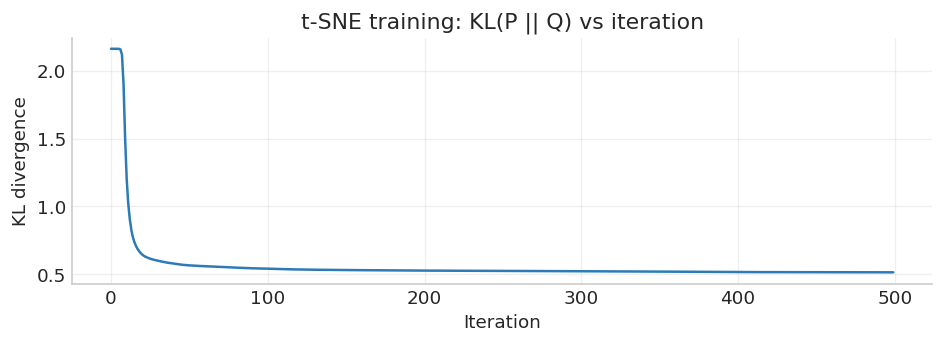

In [14]:
# Plot the KL divergence curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tsne_ours.kl_curve_, color=COLORS[0], lw=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('KL divergence')
ax.set_title('t-SNE training: KL(P || Q) vs iteration')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Що ми бачимо - крива KL-дивергенції

KL-дивергенція вимірює, наскільки $Q$ (розташування у 2-D) відрізняється від $P$
(справжні сусідства в $d$-D). Чим менша KL - тим вірніше 2-D вкладення відображає
структуру вихідних даних.

- **Початок (великі значення):** усі точки зліплені разом у випадковому місці -
  $Q$ майже рівномірна, а $P$ має структуру. Розбіжність велика.
- **Різкий спад (перші 100–150 ітерацій):** кластери «розліпляються» і займають
  свої позиції. Це найбільш продуктивна фаза навчання.
- **Вирівнювання (після ~200 ітерацій):** глобальна структура сформована,
  залишаються дрібні локальні корекції.

Якщо крива не знижується або підскакує - зменшіть `learning_rate`.
Якщо крива ще не вирівнялася до кінця - збільшіть `n_iter`.

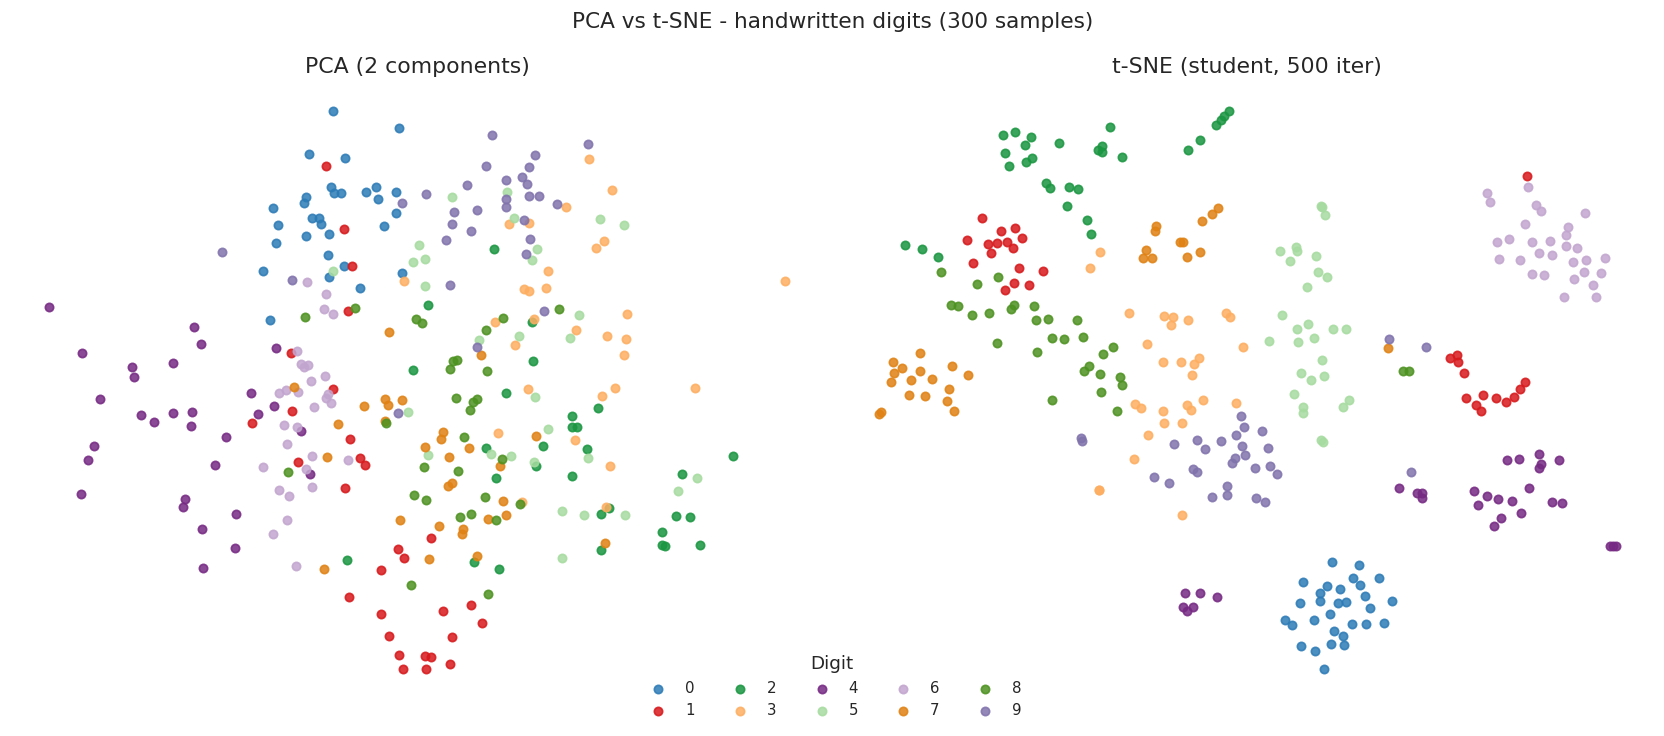

In [15]:
# Side-by-side: PCA vs student t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Y, title in zip(axes,
                         [X_pca, Y_ours],
                         ['PCA (2 components)', 't-SNE (student, 500 iter)']):
    for c, col in zip(range(10), COLORS):
        mask = y_sub == c
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   color=col, label=str(c), s=25, alpha=0.85)
    ax.set_title(title)
    ax.axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Digit', ncol=5,
           loc='lower center', bbox_to_anchor=(0.5, -0.02), fontsize=9)
plt.suptitle('PCA vs t-SNE - handwritten digits (300 samples)', fontsize=13)
plt.tight_layout(); plt.show()

#### Що ми бачимо - PCA vs t-SNE

**PCA (ліворуч):** лінійна проекція. Кілька класів частково виокремлені,
але більшість утворює одну велику хмару в центрі.
Осі мають змістовну інтерпретацію - це напрямки максимальної дисперсії.

**t-SNE (праворуч):** нелінійне вкладення. Кожен клас утворює
окремий острівець. Це результат того, що алгоритм напряму оптимізує
збереження сусідства, а не дисперсії.

Важлива застереження щодо t-SNE:

- **Осі не мають інтерпретації**: "ліво-право" та "вгору-вниз" у t-SNE
  не означають нічого конкретного на відміну від PC1/PC2.
- **Відстані між кластерами ненадійні**: те, що кластери 3 і 5 виглядають
  ближче за 0 і 9 - не обов'язково відображає реальну схожість у 64-D.
  t-SNE добре зберігає локальну структуру, але не глобальну.
- **Розмір кластерів нічого не значить**: великий кластер не означає
  більш щільний або компактний клас у вихідному просторі.

---
## 4. - Вплив параметра `perplexity`

Perplexity - найважливіший гіперпараметр t-SNE. Він контролює,
**скільки сусідів вважаються «значущими»** для кожної точки.

Технічно: perplexity = $2^{H(P_i)}$, де $H$ - ентропія розподілу $P_i$.
Але практично можна думати про нього як про *ефективний розмір кола сусідів*.

| perplexity | Що бачить алгоритм | Очікуваний ефект |
|-----------|---------------------|------------------|
| 5 | Тільки 5 найближчих сусідів | Дрібна локальна структура, багато ізольованих острівців |
| 20–40 | ~20–40 сусідів | Робочий діапазон, баланс локальне/глобальне |
| 100 | ~100 сусідів | Кластери зливаються; для 300 точок це забагато |

Практичне правило: тримайте perplexity між $\sqrt{n}$ і $n/3$.
Для $n = 300$: приблизно від **17 до 100**, оптимум зазвичай близько **20–40**.

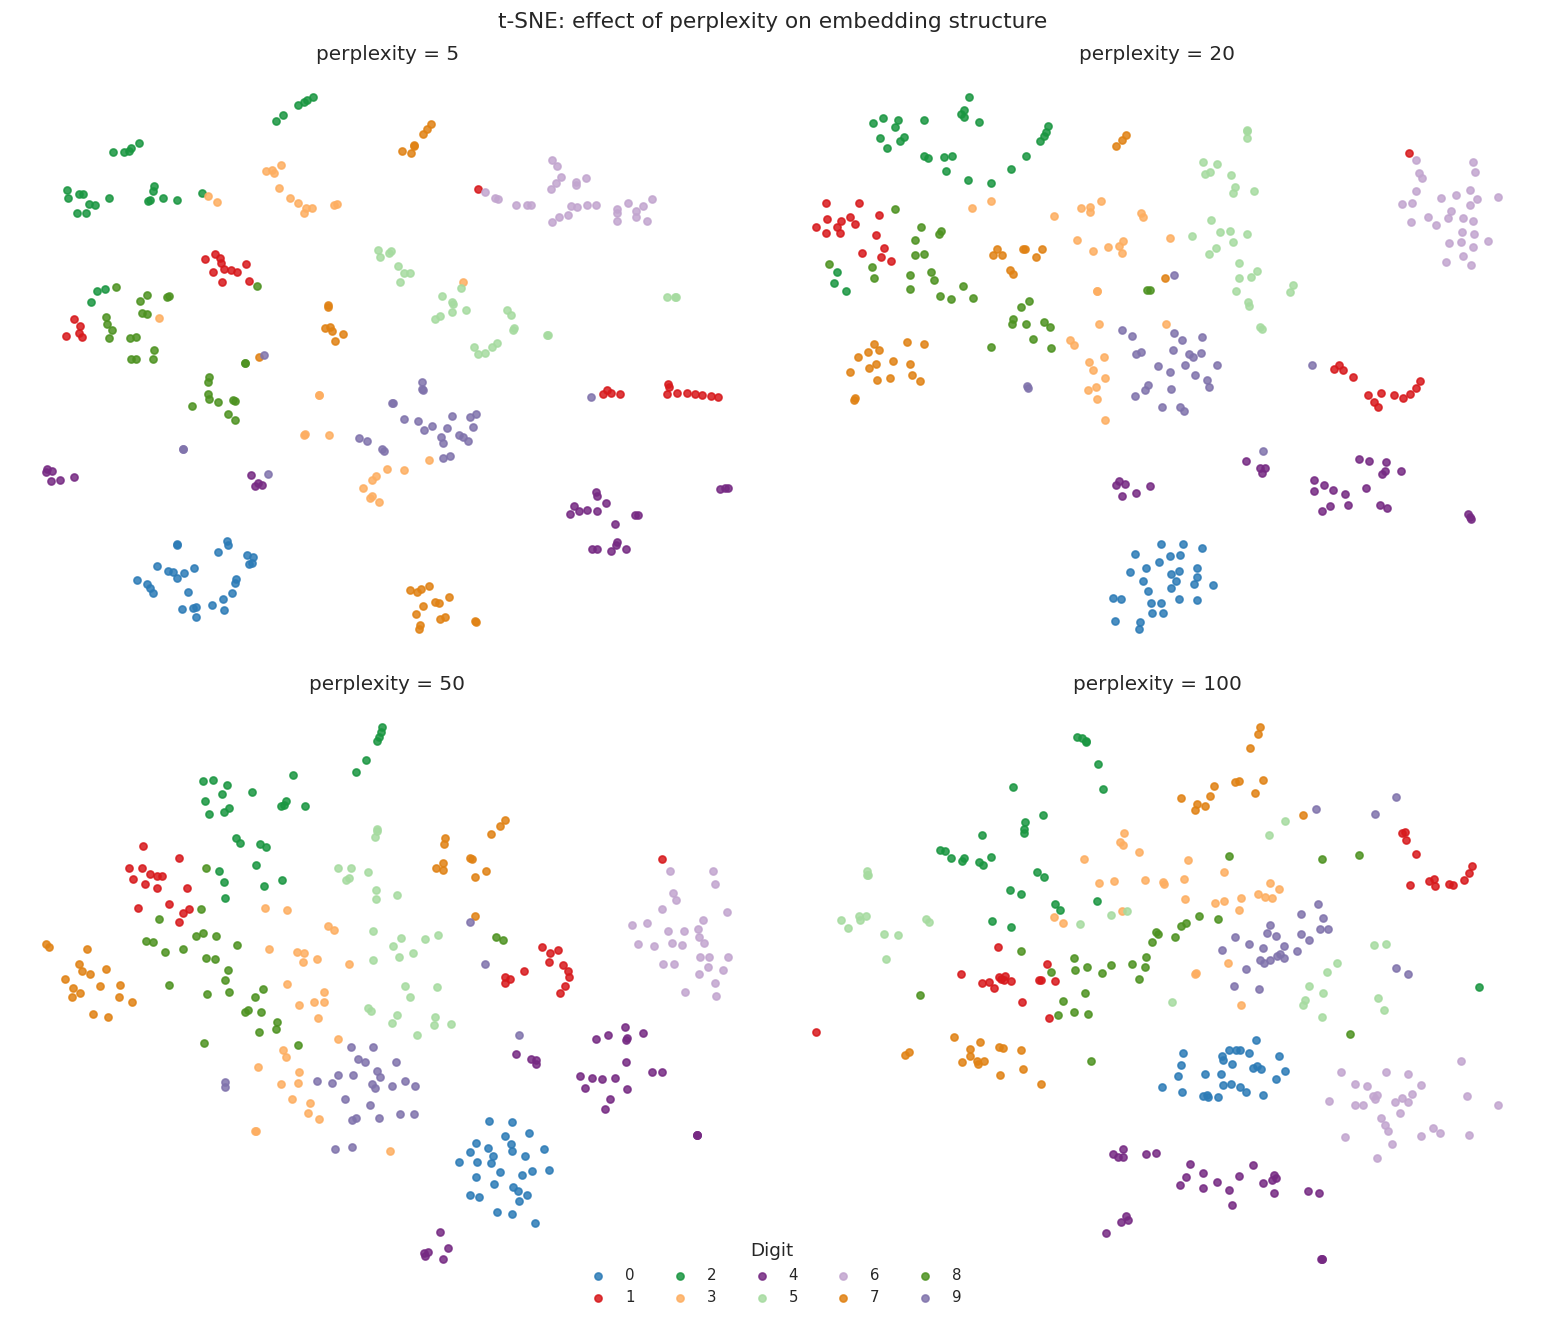

In [16]:
perplexities = [5, 20, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, perp in zip(axes.flat, perplexities):
    t = viz.TSNE(perplexity=perp, n_iter=500,
                 learning_rate=200.0, momentum=0.8, random_state=SEED)
    Y = t.fit_transform(X_scaled)
    for c, col in zip(range(10), COLORS):
        mask = y_sub == c
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   color=col, label=str(c), s=18, alpha=0.85)
    ax.set_title(f'perplexity = {perp}', fontsize=12)
    ax.axis('off')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Digit', ncol=5,
           loc='lower center', bbox_to_anchor=(0.5, -0.01), fontsize=9)
plt.suptitle('t-SNE: effect of perplexity on embedding structure', fontsize=13)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- **perplexity = 5:** кожна точка враховує лише 5 найближчих сусідів.
  Кластери розпадаються на дрібні фрагменти: частини одного класу
  можуть опинитися в різних кінцях графіка. Глобальна структура втрачена.

- **perplexity = 20:** хороший баланс. Класи утворюють компактні острівці,
  не зливаючись між собою. Це типово рекомендований діапазон.

- **perplexity = 50:** кластери трохи більші і менш щільні.
  Алгоритм «бачить далі» і намагається зберегти більш глобальну структуру.
  Для деяких схожих класів (наприклад, 3 і 5) межі стають менш чіткими.

- **perplexity = 100:** для 300 точок це означає, що кожна точка «дружить»
  приблизно з третиною датасету. Кластери починають зливатися,
  t-SNE поводиться все більше як PCA - намагається зберегти глобальну дисперсію.

**Важливий висновок:** немає «правильного» значення perplexity - воно залежить
від датасету. Завжди варто спробувати кілька значень.

---
## 5. - Повне порівняння: PCA, t-SNE (власний), t-SNE (sklearn), UMAP

### UMAP - ще один погляд на сусідство

UMAP (Uniform Manifold Approximation and Projection, McInnes et al. 2018)
вирішує ту саму задачу, що й t-SNE, але іншим способом.

**Основна ідея UMAP простими словами:**

1. Побудуйте **граф сусідства** у вихідному просторі: кожну точку
   з'єднайте з її $k$ найближчими сусідами ребрами різної ваги
   (ближчі сусіди - товстіші ребра).
2. Знайдіть 2-D вкладення, яке зберігає **топологію цього графа**:
   якщо два вузли з'єднані - вони мають бути поруч; роз'єднані - далеко.

**Чим UMAP відрізняється від t-SNE:**

| | t-SNE | UMAP |
|---|---|---|
| **Збереження** | Переважно локальна структура | Локальна + краще глобальна |
| **Швидкість** | $O(n^2)$ - повільно | $O(n^{1.1})$ - значно швидше |
| **Параметри** | `perplexity`, `learning_rate` | `n_neighbors`, `min_dist` |
| **Детермінізм** | Ні (залежить від init) | Ні (але стабільніший) |
| **Відстані між кластерами** | Ненадійні | Більш значущі |

Параметр `n_neighbors` в UMAP грає роль, аналогічну `perplexity` в t-SNE:
малі значення - дрібна структура, великі - глобальна.

### 5a - Порівняння на датасеті digits

In [17]:
# sklearn t-SNE: same algorithm but with init='pca' and learning_rate='auto'
# These defaults make convergence more reliable than our hand-tuned version
tsne_sk = SklearnTSNE(n_components=2, perplexity=30,
                       learning_rate='auto', init='pca',
                       random_state=SEED)
Y_sk    = tsne_sk.fit_transform(X_scaled)

umap_model = umap.UMAP(n_components=2, n_neighbors=15,
                        min_dist=0.1, random_state=SEED)
Y_umap     = umap_model.fit_transform(X_scaled)

print('sklearn t-SNE and UMAP computed.')

sklearn t-SNE and UMAP computed.


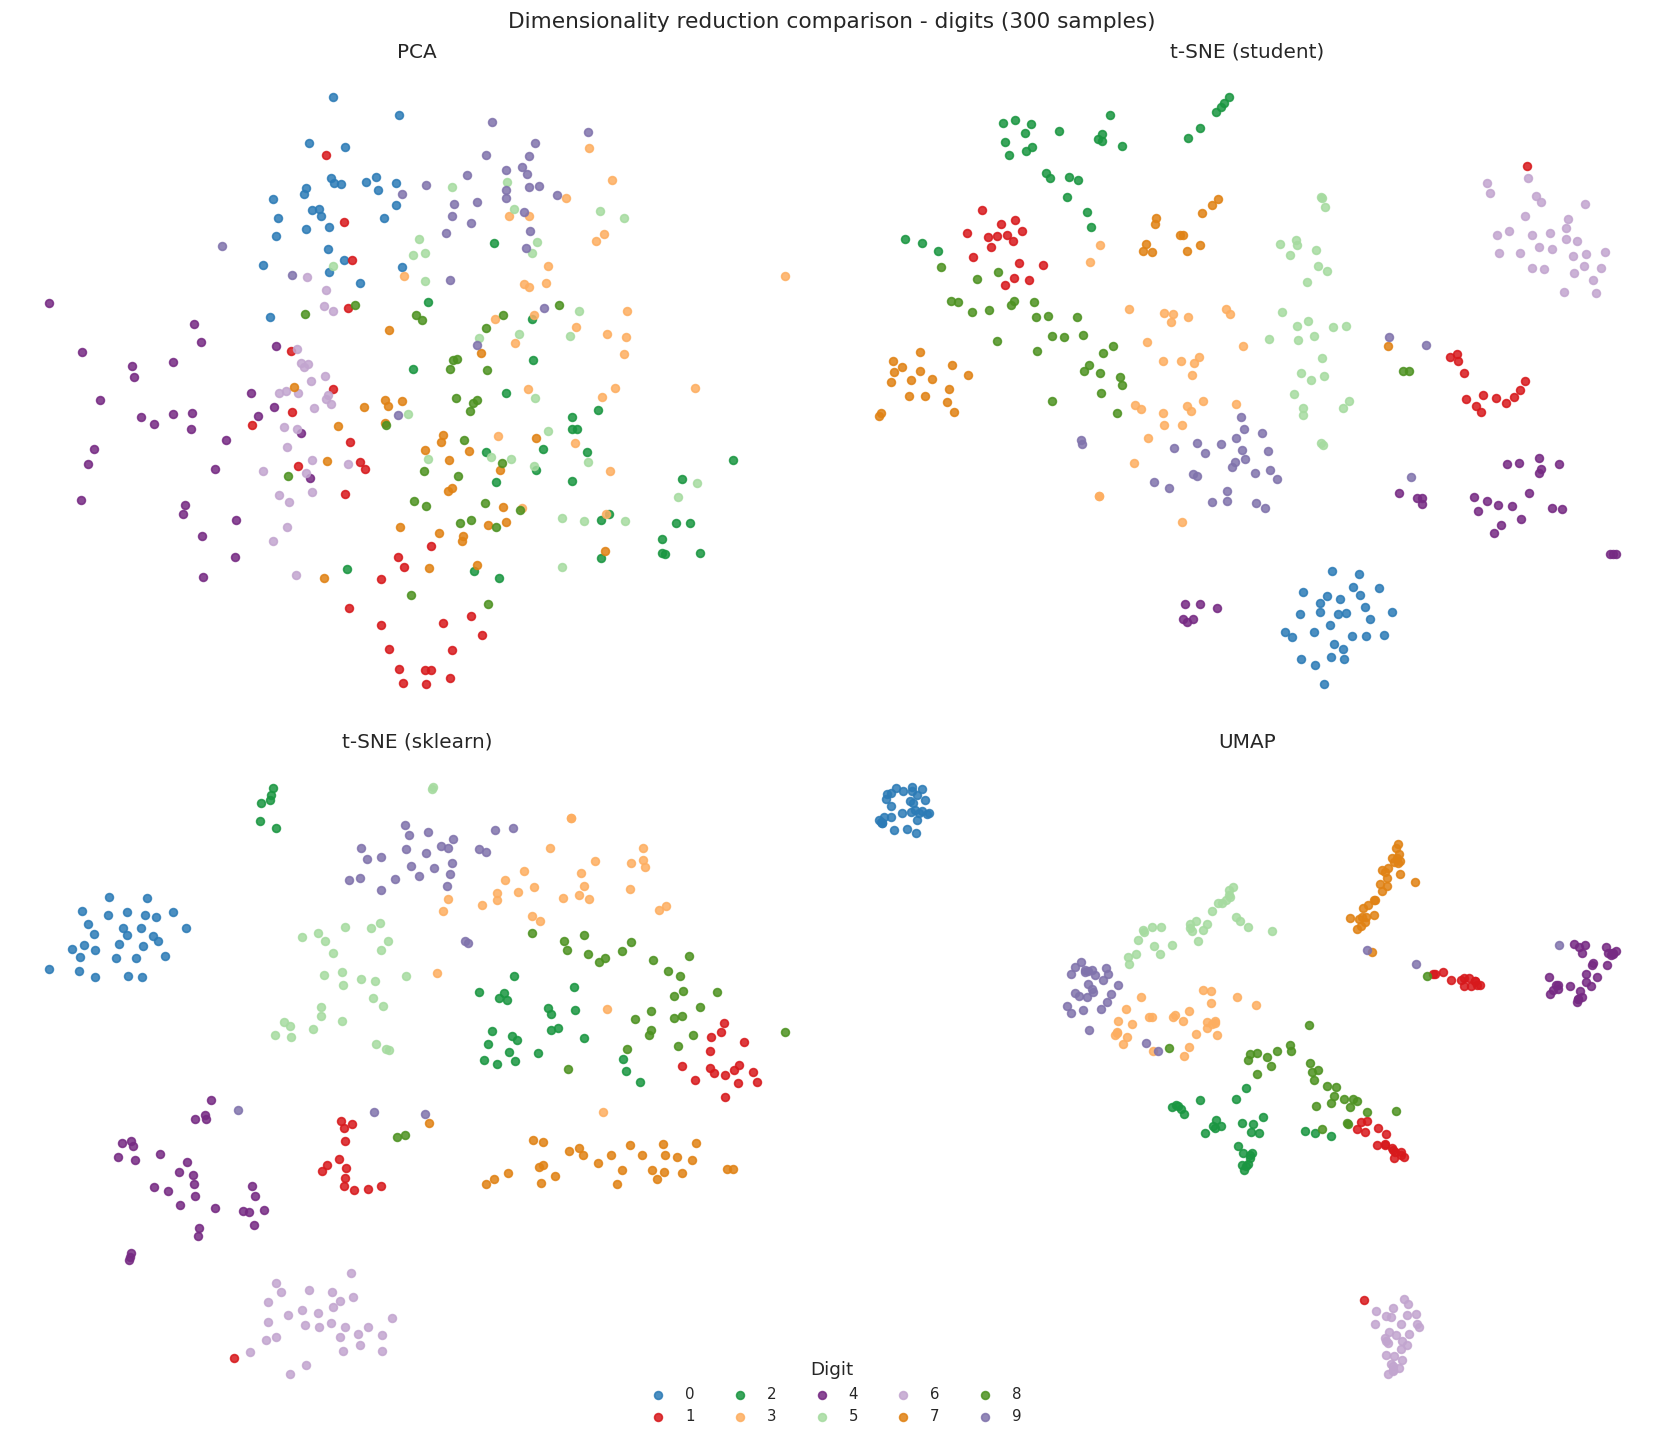

In [18]:
methods_digits = [
    ('PCA',              X_pca),
    ('t-SNE (student)',  Y_ours),
    ('t-SNE (sklearn)',  Y_sk),
    ('UMAP',             Y_umap),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, Y) in zip(axes.flat, methods_digits):
    for c, col in zip(range(10), COLORS):
        mask = y_sub == c
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   color=col, label=str(c), s=22, alpha=0.85)
    ax.set_title(name, fontsize=12)
    ax.axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Digit', ncol=5,
           loc='lower center', bbox_to_anchor=(0.5, -0.01), fontsize=9)
plt.suptitle('Dimensionality reduction comparison - digits (300 samples)', fontsize=13)
plt.tight_layout(); plt.show()

#### Що ми бачимо - digits

**PCA:** приблизно 22% дисперсії. Деякі класи частково відокремлені,
але більшість перекривається. Метод не знає про структуру класів.

**t-SNE (власний):** кластери чіткіші ніж у PCA, але можлива нестабільність:
наш алгоритм ініціалізується випадково і не має ранньої перебільшеності (early
exaggeration). Деякі класи можуть бути злиті або розбиті на фрагменти.

**t-SNE (sklearn):** та сама математика, але з `init='pca'` (стабільніша
ініціалізація) та автоматичним підбором learning rate. Зазвичай дає
чіткіші та відтворюваніші кластери.

**UMAP:** подібне до sklearn t-SNE за якістю кластеризації, але часто
краще зберігає відносні відстані між кластерами. Зверніть увагу:
розташування кластерів (де знаходяться 0, 1, 2...) буде різним у кожному методі -
це нормально, абсолютні позиції не мають значення, лише групування.

### 5b - Порівняння на датасеті Olivetti Faces

In [19]:
# Olivetti: 400 images, 40 subjects, 10 images per subject, 64x64 = 4096 features.
# We shuffle and take the first 200 images, which covers all 40 subjects
# with ~5 images each.
faces    = fetch_olivetti_faces(shuffle=True, random_state=SEED)
X_faces  = StandardScaler().fit_transform(faces.data[:200])
y_faces  = faces.target[:200]
n_subjects = len(np.unique(y_faces))
print(f'Faces subset: {X_faces.shape}   {n_subjects} subjects')

Faces subset: (200, 4096)   40 subjects


In [20]:
# Run all four methods on faces
pca_f    = pca_module.PCA(n_components=2)
Y_pca_f  = pca_f.fit_transform(X_faces)

tsne_f   = viz.TSNE(perplexity=20.0, n_iter=500,
                     learning_rate=200.0, momentum=0.8, random_state=SEED)
Y_our_f  = tsne_f.fit_transform(X_faces)

Y_sk_f   = SklearnTSNE(n_components=2, perplexity=20,
                        learning_rate='auto', init='pca',
                        random_state=SEED).fit_transform(X_faces)

Y_um_f   = umap.UMAP(n_components=2, n_neighbors=10,
                      min_dist=0.1, random_state=SEED).fit_transform(X_faces)

print('All four methods computed on faces.')

All four methods computed on faces.


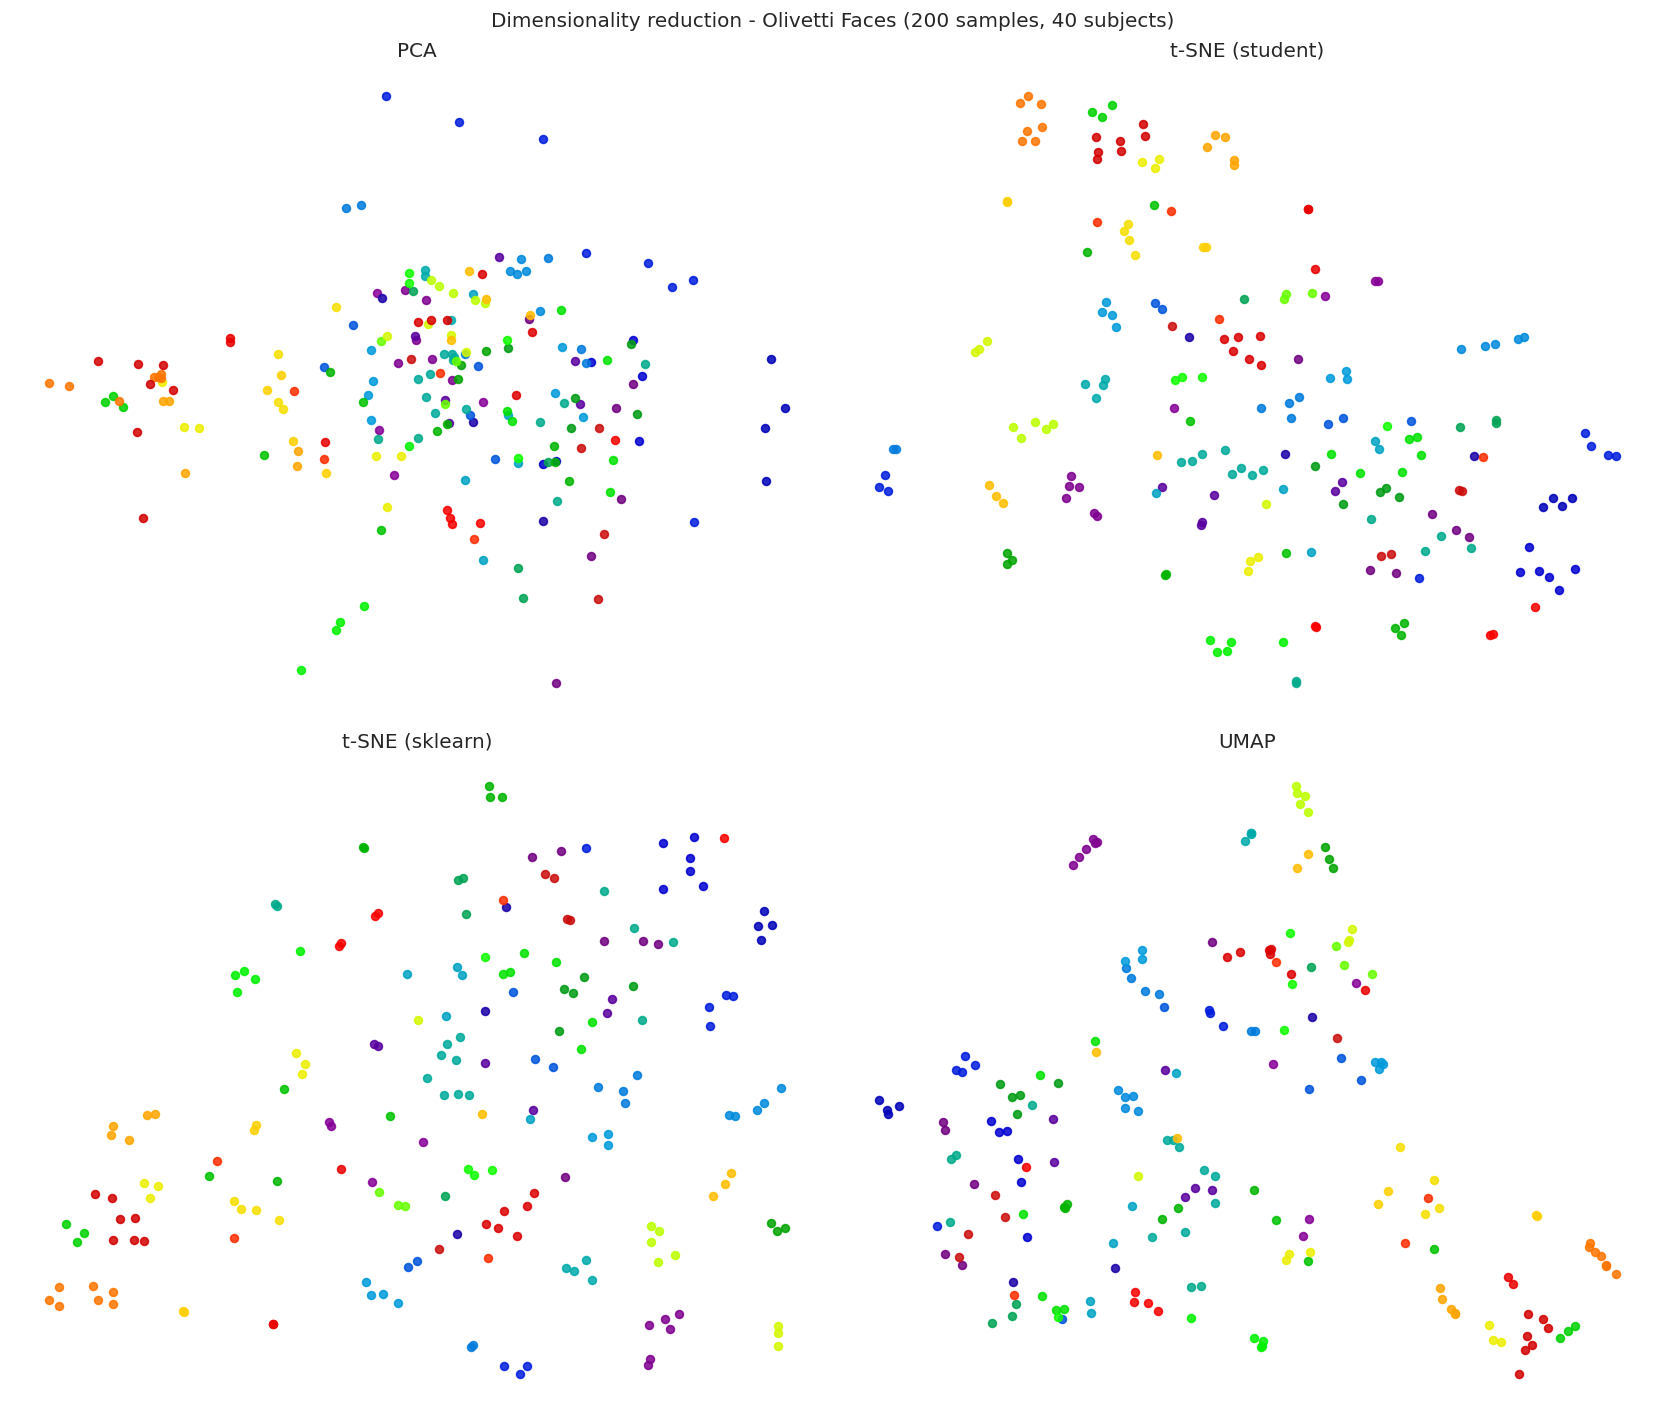

In [21]:
# 40-color palette for 40 subjects
cmap_faces  = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_subjects))

methods_faces = [
    ('PCA',             Y_pca_f),
    ('t-SNE (student)', Y_our_f),
    ('t-SNE (sklearn)', Y_sk_f),
    ('UMAP',            Y_um_f),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, Y) in zip(axes.flat, methods_faces):
    for s, col in zip(np.unique(y_faces), cmap_faces):
        mask = y_faces == s
        ax.scatter(Y[mask, 0], Y[mask, 1], color=col, s=22, alpha=0.85)
    ax.set_title(name, fontsize=12)
    ax.axis('off')
plt.suptitle(
    f'Dimensionality reduction - Olivetti Faces (200 samples, {n_subjects} subjects)',
    fontsize=12)
plt.tight_layout(); plt.show()

#### Що ми бачимо - Olivetti Faces

Датасет значно складніший за digits: 4 096 ознак замість 64,
40 суб'єктів і лише ~5 зображень на кожного після підвибірки.

**PCA:** усі 40 суб'єктів з'єднані в одну велику хмару,
де майже неможливо виокремити окремих людей.
Це пов'язано з тим, що 2 компоненти захоплюють дуже малу частку дисперсії
у 4 096-вимірному просторі.

**t-SNE та UMAP:** помітні невеликі острівці одного кольору -
зображення одного і того самого суб'єкта групуються разом.
Якість групування залежить від кількості зображень:
суб'єкти з усіма 5 зображеннями (однаковий колір) утворюють чіткіші кластери.

**Порівняння t-SNE (student) vs sklearn:** на складному датасеті
різниця між реалізаціями стає більш помітною. Sklearn t-SNE,
ймовірно, дасть чіткіші острівці завдяки кращій ініціалізації.

**UMAP:** зазвичай краще зберігає глобальну структуру (які суб'єкти
схожі одне на одного) разом із локальними кластерами.

---
## Підсумок

| Метод | Ключовий висновок |
|-------|-------------------|
| **PCA** | Швидкий, детермінований, осі інтерпретовані; лінійний - не розділяє нелінійні кластери; захоплює ~22% дисперсії digits у 2-D |
| **t-SNE (власний)** | Нелінійне вкладення через мінімізацію KL$(P\|Q)$; добре відокремлює кластери; $O(n^2)$; чутливий до `perplexity`, `learning_rate` та ініціалізації |
| **t-SNE (sklearn)** | Та сама математика з `init='pca'` та `learning_rate='auto'`; стабільніша збіжність на практиці |
| **UMAP** | Граф-базований; швидший за t-SNE; краще зберігає глобальну структуру; відстані між кластерами більш значущі |
| **perplexity / n_neighbors** | Малі значення - локальна структура; великі - глобальна; для $n=300$ оптимум зазвичай 20–40 |
| **Застереження** | Осі t-SNE/UMAP не інтерпретовані; розміри та відстані між кластерами в t-SNE ненадійні; завжди порівнюйте з PCA як базовим рівнем |
